In [98]:
# Import libraries
import pandas as pd
import numpy as np

In [99]:
#showing the path for the file we like to analyze
filename = r'C:\Users\Achu\Documents\University of Calgary\Data 601 - Working with data and visualization\Project\medallists.csv'

In [100]:
#Reading the csv file in a dataframe
df = pd.read_csv(filename)

In [101]:
#identifying the datatypes of all the columns in our dataframe

df.dtypes


medal_date           object
medal_type           object
medal_code          float64
name                 object
gender               object
country_code         object
country              object
country_long         object
nationality_code     object
nationality          object
nationality_long     object
team                 object
team_gender          object
discipline           object
event                object
event_type           object
url_event            object
birth_date           object
code_athlete          int64
code_team            object
is_medallist           bool
dtype: object

In [102]:
#Understanding the data for further processing
df.head()

,medal_date,medal_type,medal_code,name,gender,country_code,country,country_long,nationality_code,nationality,...,team,team_gender,discipline,event,event_type,url_event,birth_date,code_athlete,code_team,is_medallist
0,2024-07-27,Gold Medal,1.0,EVENEPOEL Remco,Male,BEL,Belgium,Belgium,BEL,Belgium,...,NaN,NaN,Cycling Road,Men's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/men-s-indi...,2000-01-25,1903136,NaN,True
1,2024-07-27,Silver Medal,2.0,GANNA Filippo,Male,ITA,Italy,Italy,ITA,Italy,...,NaN,NaN,Cycling Road,Men's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/men-s-indi...,1996-07-25,1923520,NaN,True
2,2024-07-27,Bronze Medal,3.0,van AERT Wout,Male,BEL,Belgium,Belgium,BEL,Belgium,...,NaN,NaN,Cycling Road,Men's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/men-s-indi...,1994-09-15,1903147,NaN,True
3,2024-07-27,Gold Medal,1.0,BROWN Grace,Female,AUS,Australia,Australia,AUS,Australia,...,NaN,NaN,Cycling Road,Women's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/women-s-in...,1992-07-07,1940173,NaN,True
4,2024-07-27,Silver Medal,2.0,HENDERSON Anna,Female,GBR,Great Britain,Great Britain,GBR,Great Britain,...,NaN,NaN,Cycling Road,Women's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/women-s-in...,1998-11-14,1912525,NaN,True


In [103]:
#finding out if we have any missing values in our dataset
df.isna().sum()

medal_date            0
medal_type            0
medal_code            1
name                  0
gender                0
country_code          0
country               0
country_long          0
nationality_code      1
nationality           1
nationality_long      1
team                760
team_gender         760
discipline            0
event                 0
event_type            0
url_event            21
birth_date            0
code_athlete          0
code_team           760
is_medallist          0
dtype: int64

In [104]:
df.shape

(2315, 21)

In [105]:
#Converting the date column from object to the datetime format 
df['medal_date'] = pd.to_datetime(df['medal_date'])

In [106]:
#Identify the duplicates
duplicated_rows = df.duplicated(subset = ['medal_date','medal_type','country_code','country','team','discipline','event','code_team'])
duplicated_rows

0       False
1       False
2       False
3       False
4       False
        ...  
2310    False
2311     True
2312     True
2313     True
2314     True
Length: 2315, dtype: bool

In [107]:
#removing the duplicated values keeping the first row
df = df.drop_duplicates(subset = ['medal_date','medal_type','country_code','country','team','discipline','event','code_team'],keep = 'first')

In [108]:
df.shape

(1044, 21)

In [109]:
#Dropping the columns that will not be used in our analysis
columns_to_drop = ['name','country_long','nationality_code','nationality_long', 'team_gender',  'url_event','birth_date','code_athlete','team', 'discipline','event','code_team' ]

df = df.drop(columns = columns_to_drop)

In [110]:
#Understanding the data after dropping the unnecessary columns
df.head()

,medal_date,medal_type,medal_code,gender,country_code,country,nationality,event_type,is_medallist
0,2024-07-27,Gold Medal,1.0,Male,BEL,Belgium,Belgium,ATH,True
1,2024-07-27,Silver Medal,2.0,Male,ITA,Italy,Italy,ATH,True
2,2024-07-27,Bronze Medal,3.0,Male,BEL,Belgium,Belgium,ATH,True
3,2024-07-27,Gold Medal,1.0,Female,AUS,Australia,Australia,ATH,True
4,2024-07-27,Silver Medal,2.0,Female,GBR,Great Britain,Great Britain,ATH,True


In [111]:
df.shape

(1044, 9)

In [112]:
#checking if all the medals are from the same year
#nunique is a function that is used to count the number of unique/distinct values in a series
same_year = df['medal_date'].dt.year.nunique() == 1

if same_year:
    print('All medals are from the same year, good for the distribution analysis')
else:
    print('Medals are from different years, needs pre-processing')

All medals are from the same year, good for the distribution analysis


In [113]:
#Coverting the columns to their appropriate datatypes

columns_to_string = ['medal_type','country']

for i in columns_to_string:
    df[i] = df[i].astype(str)


In [114]:
#Converting the gender and the country code into categories 
df['gender'] = pd.Categorical(df['gender'])
df['country_code'] = pd.Categorical(df['country_code'])

In [115]:
df.dtypes

medal_date      datetime64[ns]
medal_type              object
medal_code             float64
gender                category
country_code          category
country                 object
nationality             object
event_type              object
is_medallist              bool
dtype: object

In [116]:
#Importing the required libraries for plotting the graph
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 400
import seaborn as sns

In [117]:
unique_country_code = df['country_code'].unique()

In [118]:
color_code = [
    "#FF6633", "#FFB399", "#FF33FF", "#FFFF99", "#00B3E6", 
    "#E6B333", "#3366E6", "#999966", "#99FF99", "#B34D4D", 
    "#80B300", "#809900", "#E6B3B3", "#6680B3", "#66991A", 
    "#FF99E6", "#CCFF1A", "#FF1A66", "#E6331A", "#33FFCC", 
    "#66994D", "#B366CC", "#4D8000", "#B33300", "#CC80CC", 
    "#66664D", "#991AFF", "#E666FF", "#4DB3FF", "#1AB399", 
    "#E666B3", "#33991A", "#CC9999", "#B3B31A", "#00E680", 
    "#4D8066", "#809980", "#E6FF80", "#1AFF33", "#999933", 
    "#FF3380", "#CCCC00", "#66E64D", "#4D80CC", "#9900B3", 
    "#E64D66", "#4DB380", "#FF4D4D", "#99E6E6", "#6666FF",
    "#003366", "#663399", "#FF6666", "#66CCFF", "#669999",
    "#FF9966", "#66FF33", "#CC3333", "#FFCC00", "#336666",
    "#33CCCC", "#99CC33", "#FF66CC", "#99CCCC", "#996699",
    "#FF99CC", "#CCCC99", "#9999CC", "#33CC66", "#FF6666",
    "#3366FF", "#9999FF", "#666633", "#CC9966", "#663333",
    "#3399FF", "#FF9966", "#FF6699", "#33FF99", "#6699FF",
    "#9966FF", "#FF9966", "#669933", "#99FF66", "#33FFCC",
    "#9933FF", "#99FFCC", "#33CCFF", "#9966CC", "#FF9933",
    "#66FF99", "#FFCC99", "#99CCFF", "#996633"
]

In [119]:
# Assign color codes based on category
color_dict = {}
for index,code in enumerate (unique_country_code):
    color_dict[code] = color_code[index]
    
color_dict

{'BEL': '#FF6633',
 'ITA': '#FFB399',
 'AUS': '#FF33FF',
 'GBR': '#FFFF99',
 'USA': '#00B3E6',
 'KOR': '#E6B333',
 'TUN': '#3366E6',
 'HKG': '#999966',
 'FRA': '#99FF99',
 'HUN': '#B34D4D',
 'KAZ': '#80B300',
 'JPN': '#809900',
 'ESP': '#E6B3B3',
 'MGL': '#6680B3',
 'SWE': '#66991A',
 'GER': '#FF99E6',
 'CAN': '#CCFF1A',
 'POL': '#FF1A66',
 'EGY': '#E6331A',
 'BRA': '#33FFCC',
 'MDA': '#66994D',
 'UZB': '#B366CC',
 'KOS': '#4D8000',
 'CHN': '#B33300',
 'IND': '#CC80CC',
 'SVK': '#66664D',
 'RSA': '#991AFF',
 'UKR': '#E666FF',
 'AZE': '#4DB3FF',
 'CRO': '#1AB399',
 'SUI': '#E666B3',
 'ROU': '#33991A',
 'IRL': '#CC9999',
 'GEO': '#B3B31A',
 'TJK': '#00E680',
 'SLO': '#4D8066',
 'MEX': '#809980',
 'GUA': '#E6FF80',
 'ARG': '#1AFF33',
 'GRE': '#999933',
 'AUT': '#FF3380',
 'NED': '#CCCC00',
 'NZL': '#66E64D',
 'ECU': '#4D80CC',
 'ISR': '#9900B3',
 'POR': '#E64D66',
 'UGA': '#4DB380',
 'ETH': '#FF4D4D',
 'AIN': '#99E6E6',
 'PHI': '#6666FF',
 'NOR': '#003366',
 'GRN': '#663399',
 'JAM': '#FF

In [120]:
df['color'] = df['country_code'].map(color_dict)

In [121]:
#creating a palette for the country_code subcategory for easy identification

palette = sns.color_palette("Accent", len(df['country_code'].unique()))

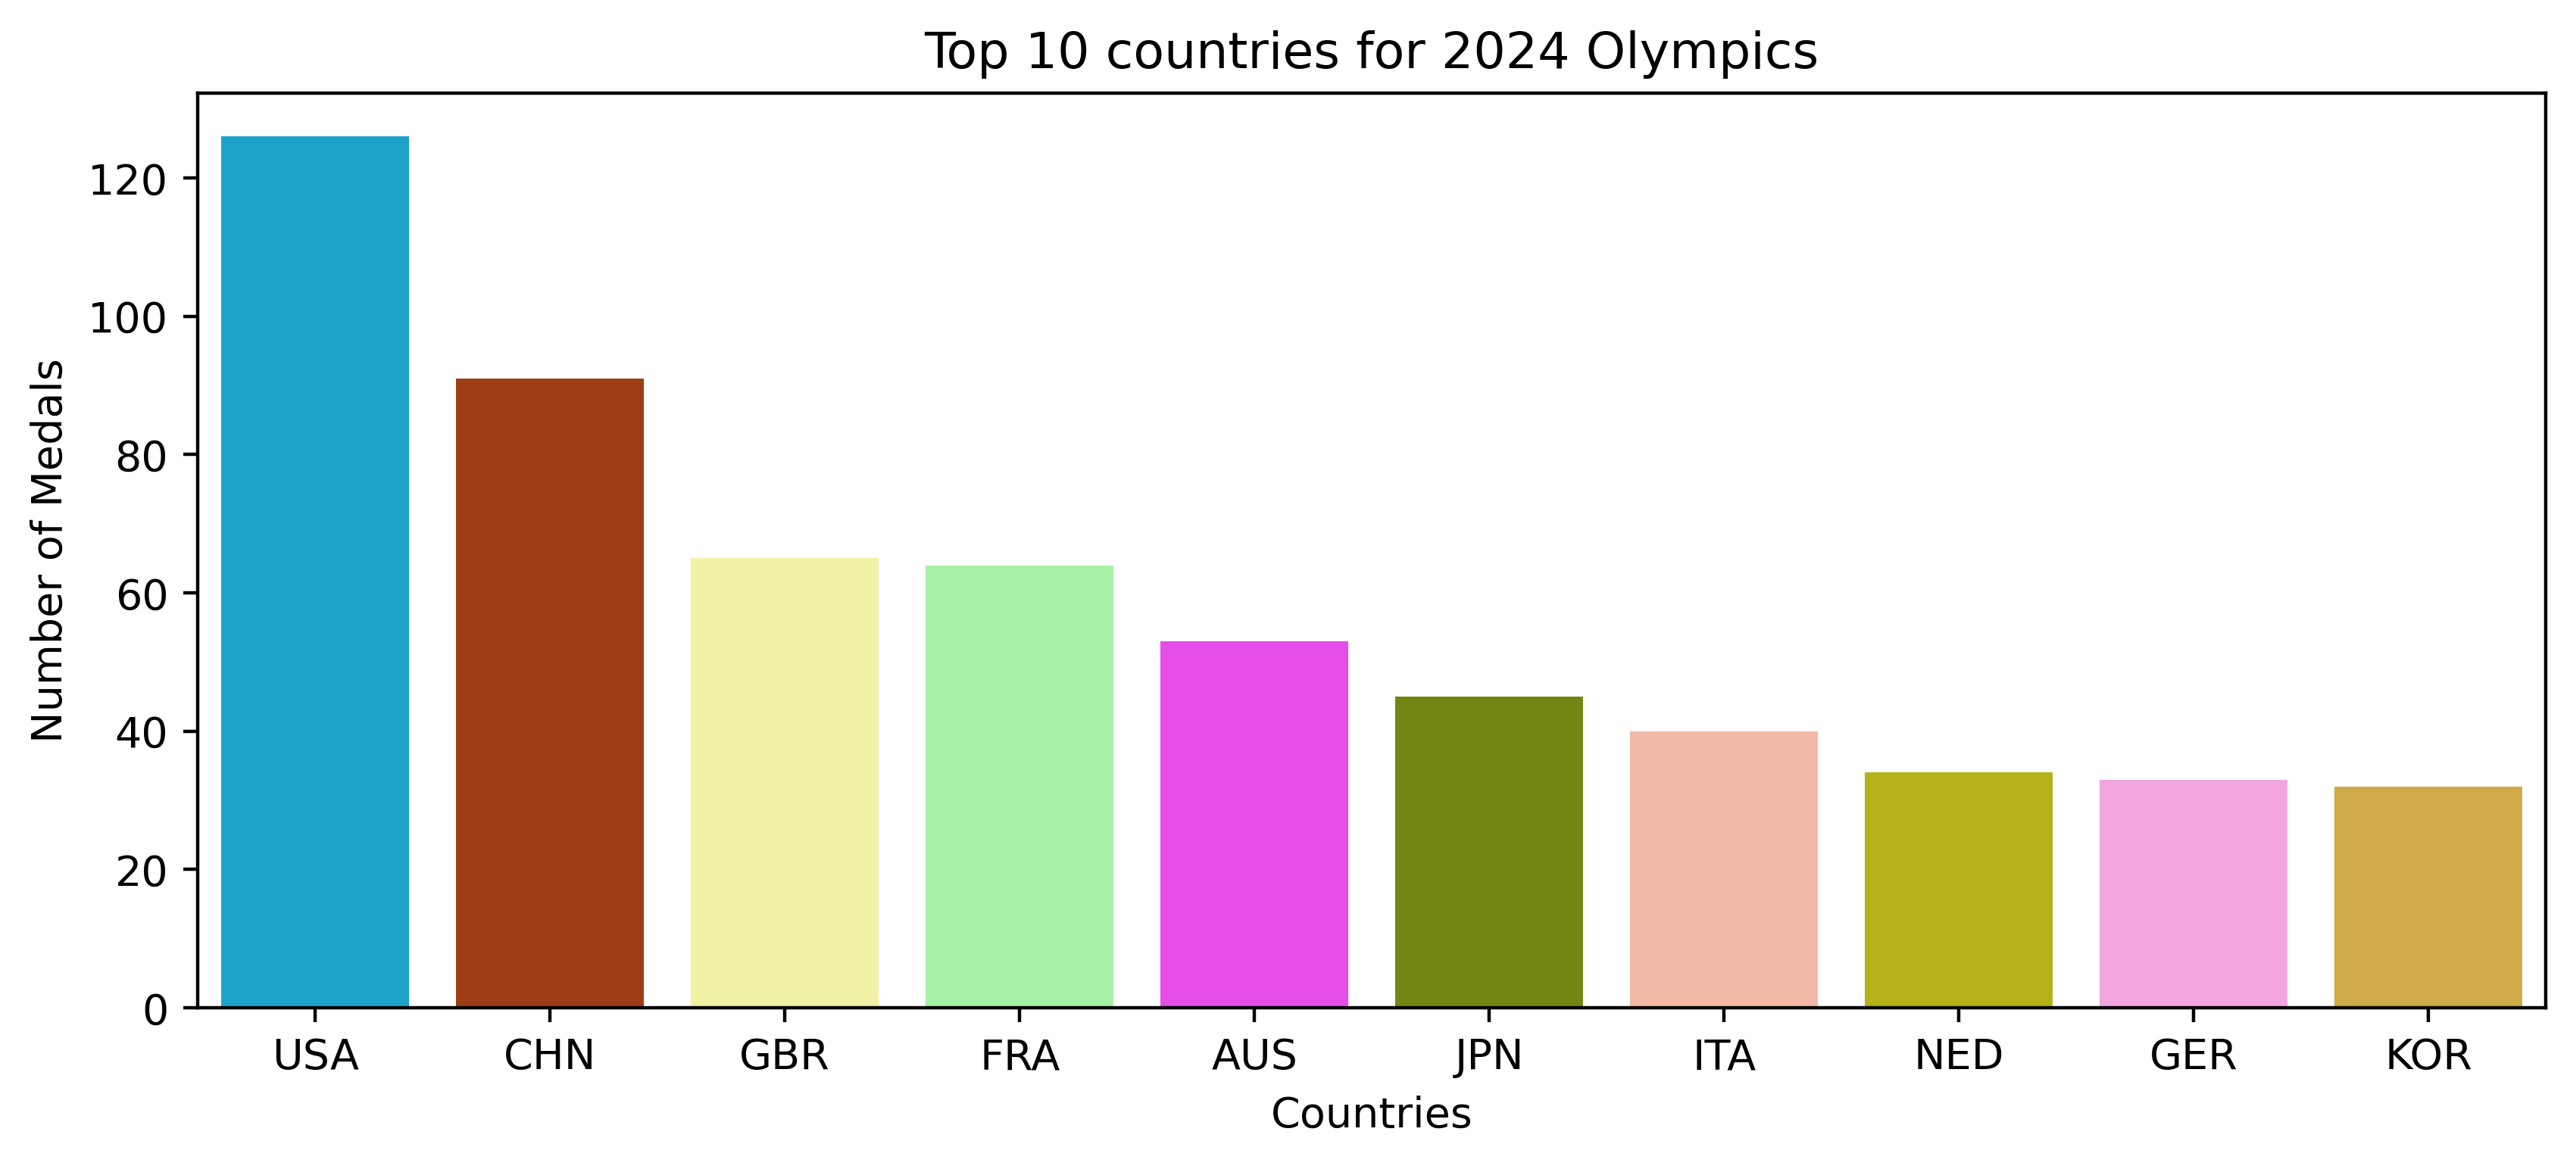

In [122]:
#Finding the top 10 countires with medals in 2024 Olympics
#.size() function counts the number of occurence during aggregation
#reset_index is used to return results back to the table
cumulative_df = df.groupby('country_code').size().reset_index(name='count')

#Sort in descending order
sorted_cumulative_df = cumulative_df.sort_values(by = 'count', ascending = False)


#Plotting the bargraph
plt.figure(figsize =(10,4))
ax = sns.barplot(x = 'country_code', y = 'count', data = sorted_cumulative_df, order=sorted_cumulative_df['country_code'].head(10), palette = color_dict)

plt.title('Top 10 countries for 2024 Olympics')
plt.xlabel('Countries')
plt.ylabel('Number of Medals')


plt.show()

In [123]:
def plot_medal_count_bar (df,title):
    

    #Providing a stacked bar to show the distribution of gold, silver and bronze across each country
    #Unstack pivote the medal_type from rows to columns. fill_value fills the empty medal_type as 0
    cumulative_medal_df = df.groupby(['country_code','medal_type']).size().unstack(fill_value=0)

    #.sum(axis= 1) calculates the total medals cross the columns
    #Sort in descending order
    cumulative_medal_df['total'] = cumulative_medal_df.sum(axis = 1)
    sorted_cumulative_medal_df = cumulative_medal_df.sort_values(by = 'total', ascending = False).head(10)

    #dropping total 
    sorted_cumulative_medal_df = sorted_cumulative_medal_df.drop(columns = 'total')

    #setting color dict
    medal_color_dict = {
        'Gold Medal' : '#FFD700',
        'Silver Medal' : '#C0C0C0',
        'Bronze Medal' : '#CD7F32'
    }

    #rearranging columns as bronze is in the beginning
    sorted_cumulative_medal_df = sorted_cumulative_medal_df[['Gold Medal', 'Silver Medal','Bronze Medal']]

    #Plotting the bargraph
    plt.figure(figsize =(10,4))
    ax = sorted_cumulative_medal_df.plot(kind = 'bar' , stacked = True , color = medal_color_dict )

    plt.title(title)
    plt.xlabel('Countries')
    plt.ylabel('Number of Medals')


    plt.show()

<Figure size 4000x1600 with 0 Axes>

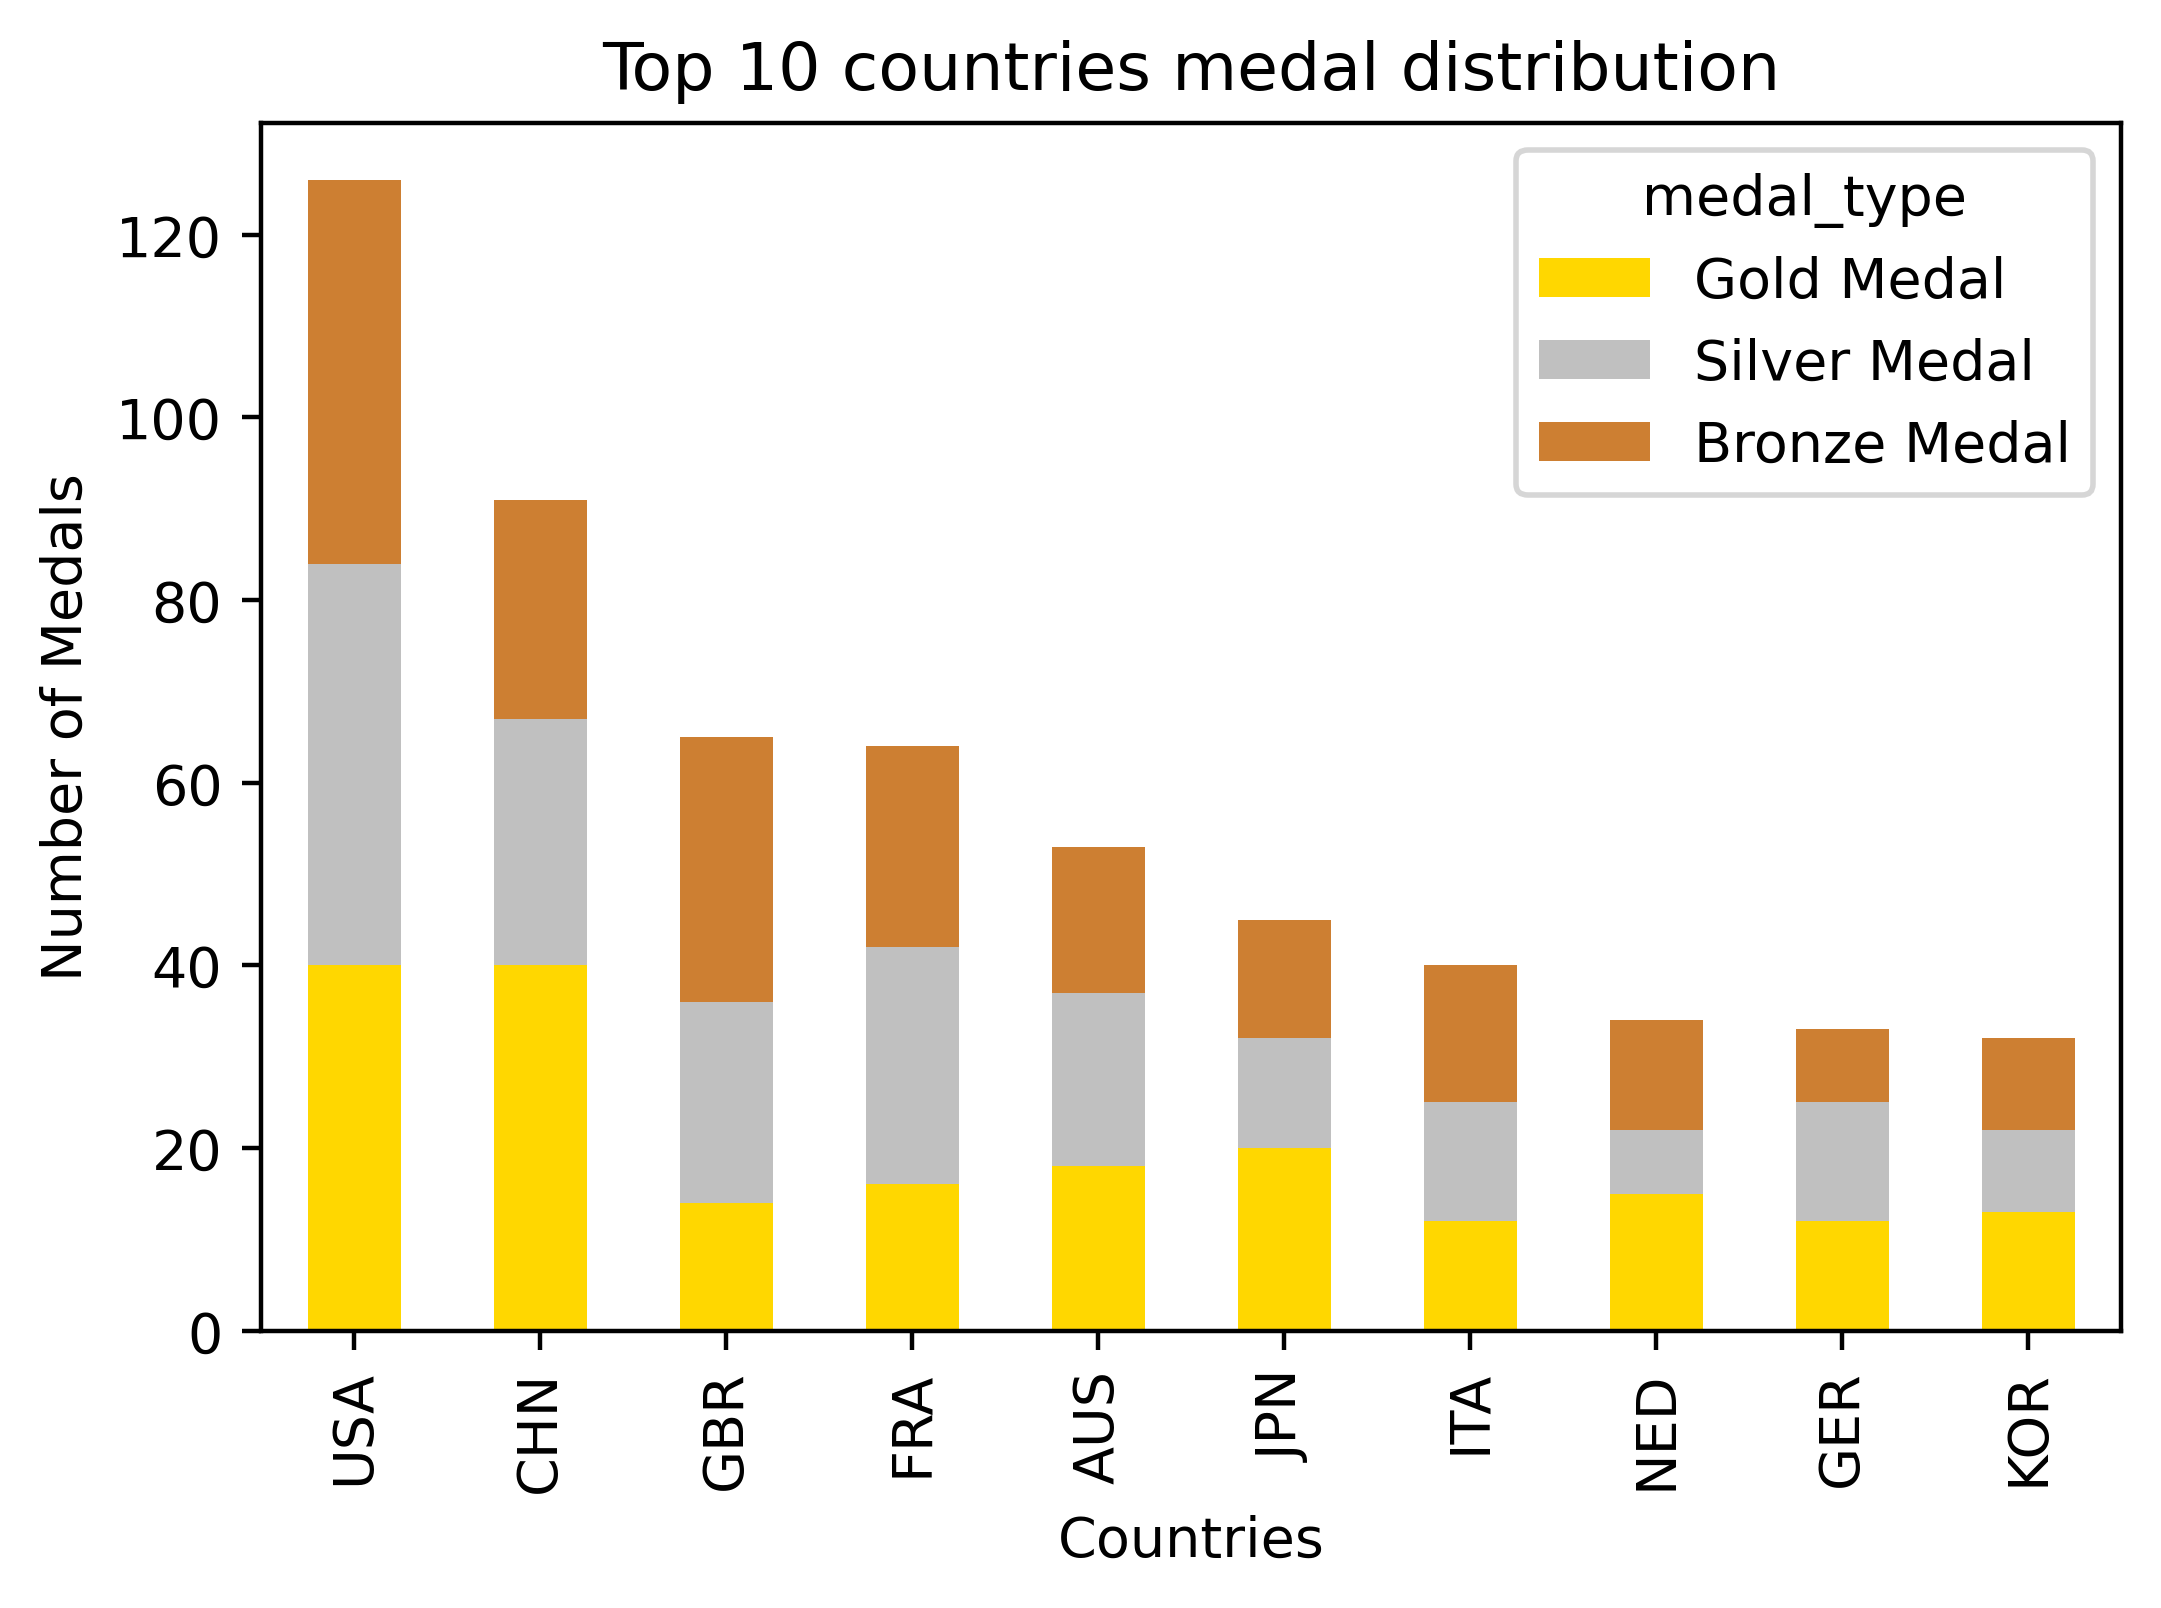

In [124]:
plot_medal_count_bar(df, 'Top 10 countries medal distribution')

In [125]:
def plot_country_event_type_compare(df, heading):
    cumulative_medal_df = df.groupby(['country_code','event_type']).size().unstack(fill_value='0')
    cumulative_medal_df['total'] = cumulative_medal_df.sum(axis = 1)
    sorted_cumulative_medal_df = cumulative_medal_df.sort_values(by = 'total', ascending = False).head(10)

    #dropping total 
    sorted_cumulative_medal_df = sorted_cumulative_medal_df.drop(columns = 'total')
    
    #Plotting the bargraph
    plt.figure(figsize =(10,4))
    ax = sns.heatmap(data = sorted_cumulative_medal_df,cmap = 'coolwarm', annot = True , center = sorted_cumulative_medal_df.mean().mean(), linewidths = 0.5, cbar_kws = {"label" : "number of medals"})

    plt.title(heading)
    plt.xlabel('event_Type')
    plt.ylabel('Countries')


    plt.show()

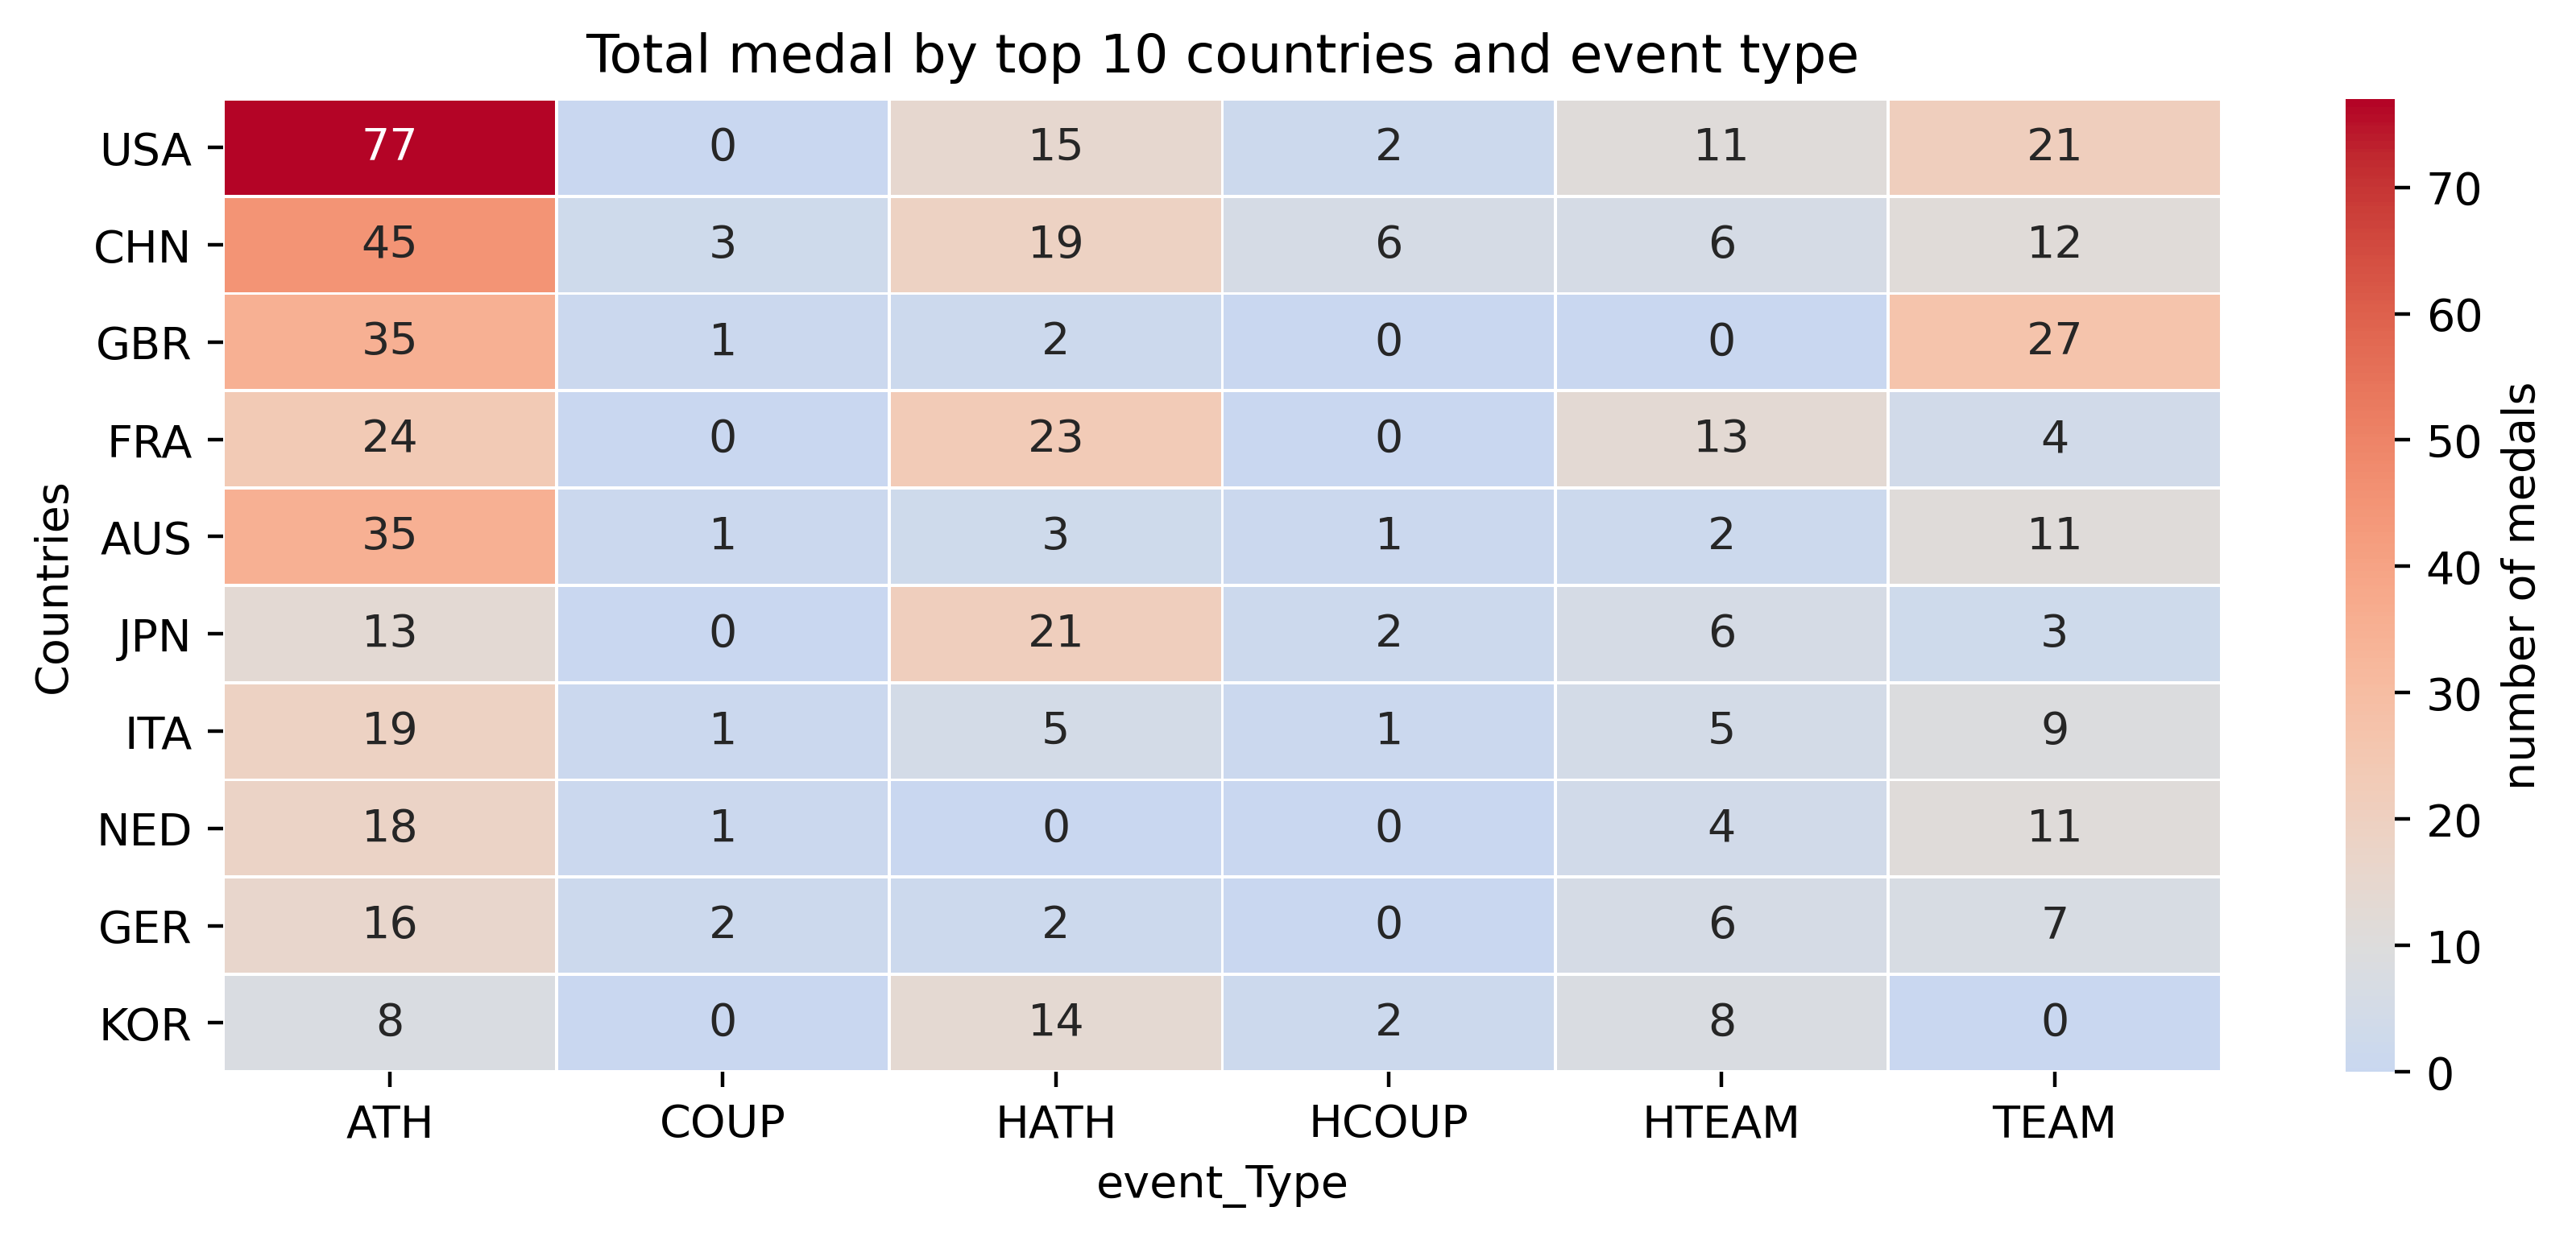

In [126]:
plot_country_event_type_compare(df, 'Total medal by top 10 countries and event type')

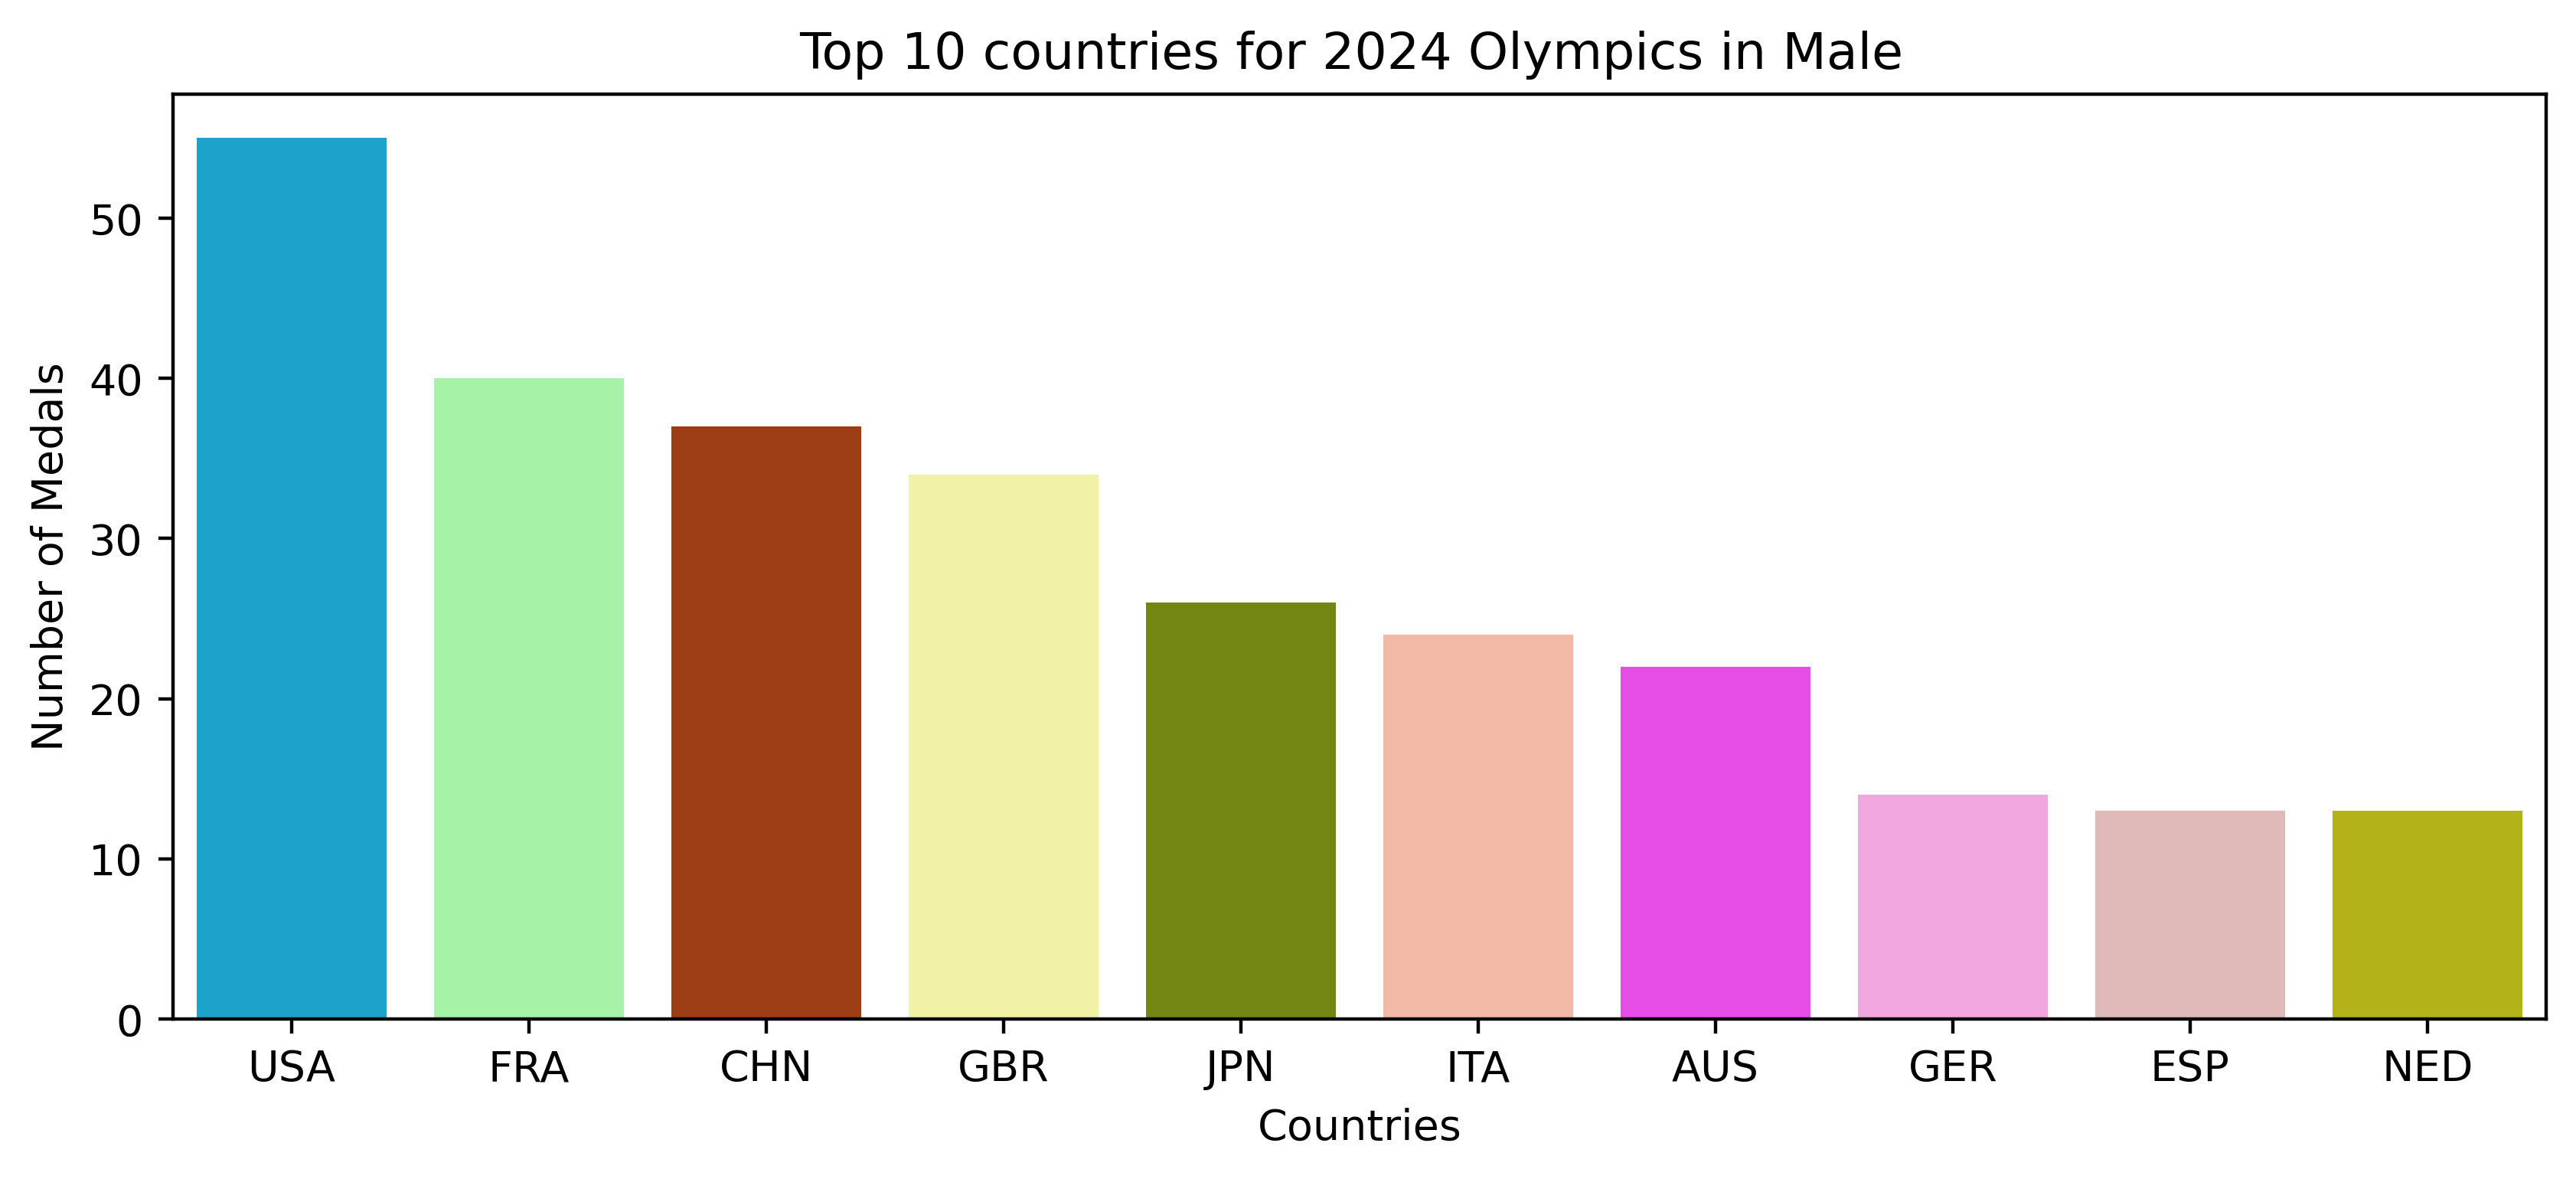

In [127]:
#Identifying the top 10 countries with medals for male
#Filtering the dataframe to include only male records
male_df = df[df['gender'] == 'Male']
male_df = male_df.groupby('country_code').size().reset_index(name='count')

#Sort in descending order
sorted_male_df = male_df.sort_values(by = 'count', ascending = False)
sorted_male_df = sorted_male_df.head(10)

#Plotting the bargraph
plt.figure(figsize =(10,4))
sns.barplot(x = 'country_code', y = 'count', data = sorted_male_df, order=sorted_male_df['country_code'].head(10), palette = color_dict)

plt.title('Top 10 countries for 2024 Olympics in Male ')
plt.xlabel('Countries')
plt.ylabel('Number of Medals')
plt.show()

<Figure size 4000x1600 with 0 Axes>

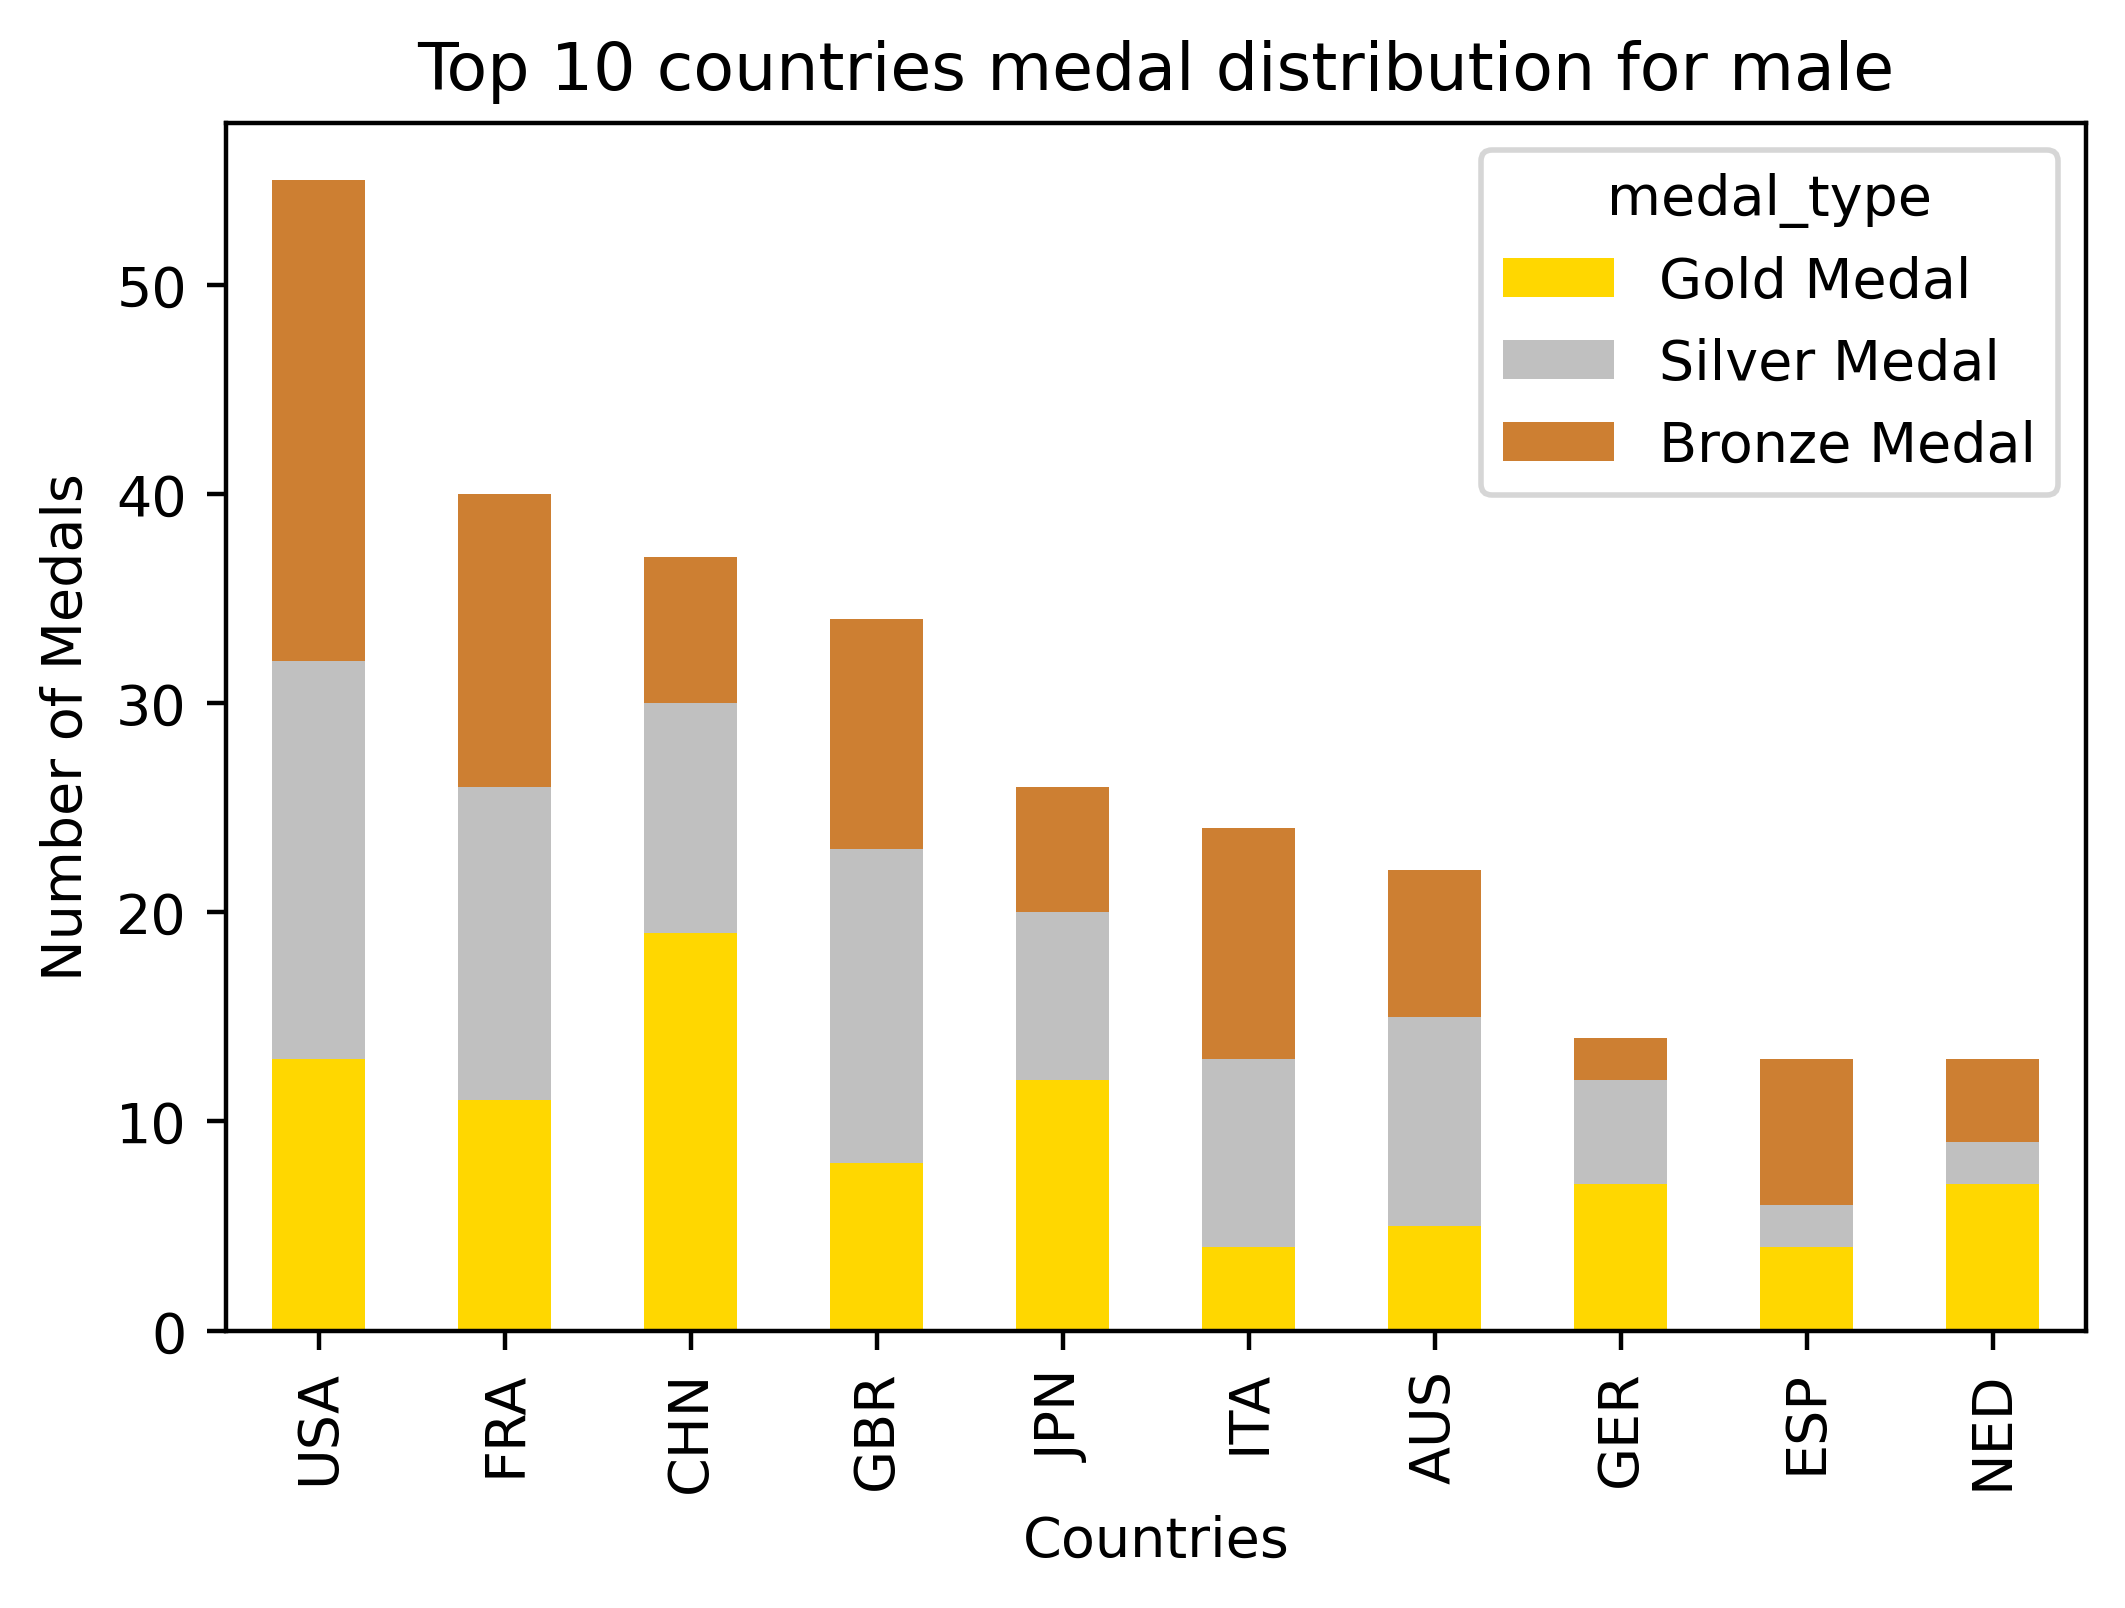

In [128]:
#Providing a stacked bar to show the distribution of gold, silver and bronze across each country
#Unstack pivote the medal_type from rows to columns. fill_value fills the empty medal_type as 0
male_df = df[df['gender'] == 'Male']

plot_medal_count_bar(male_df , 'Top 10 countries medal distribution for male')

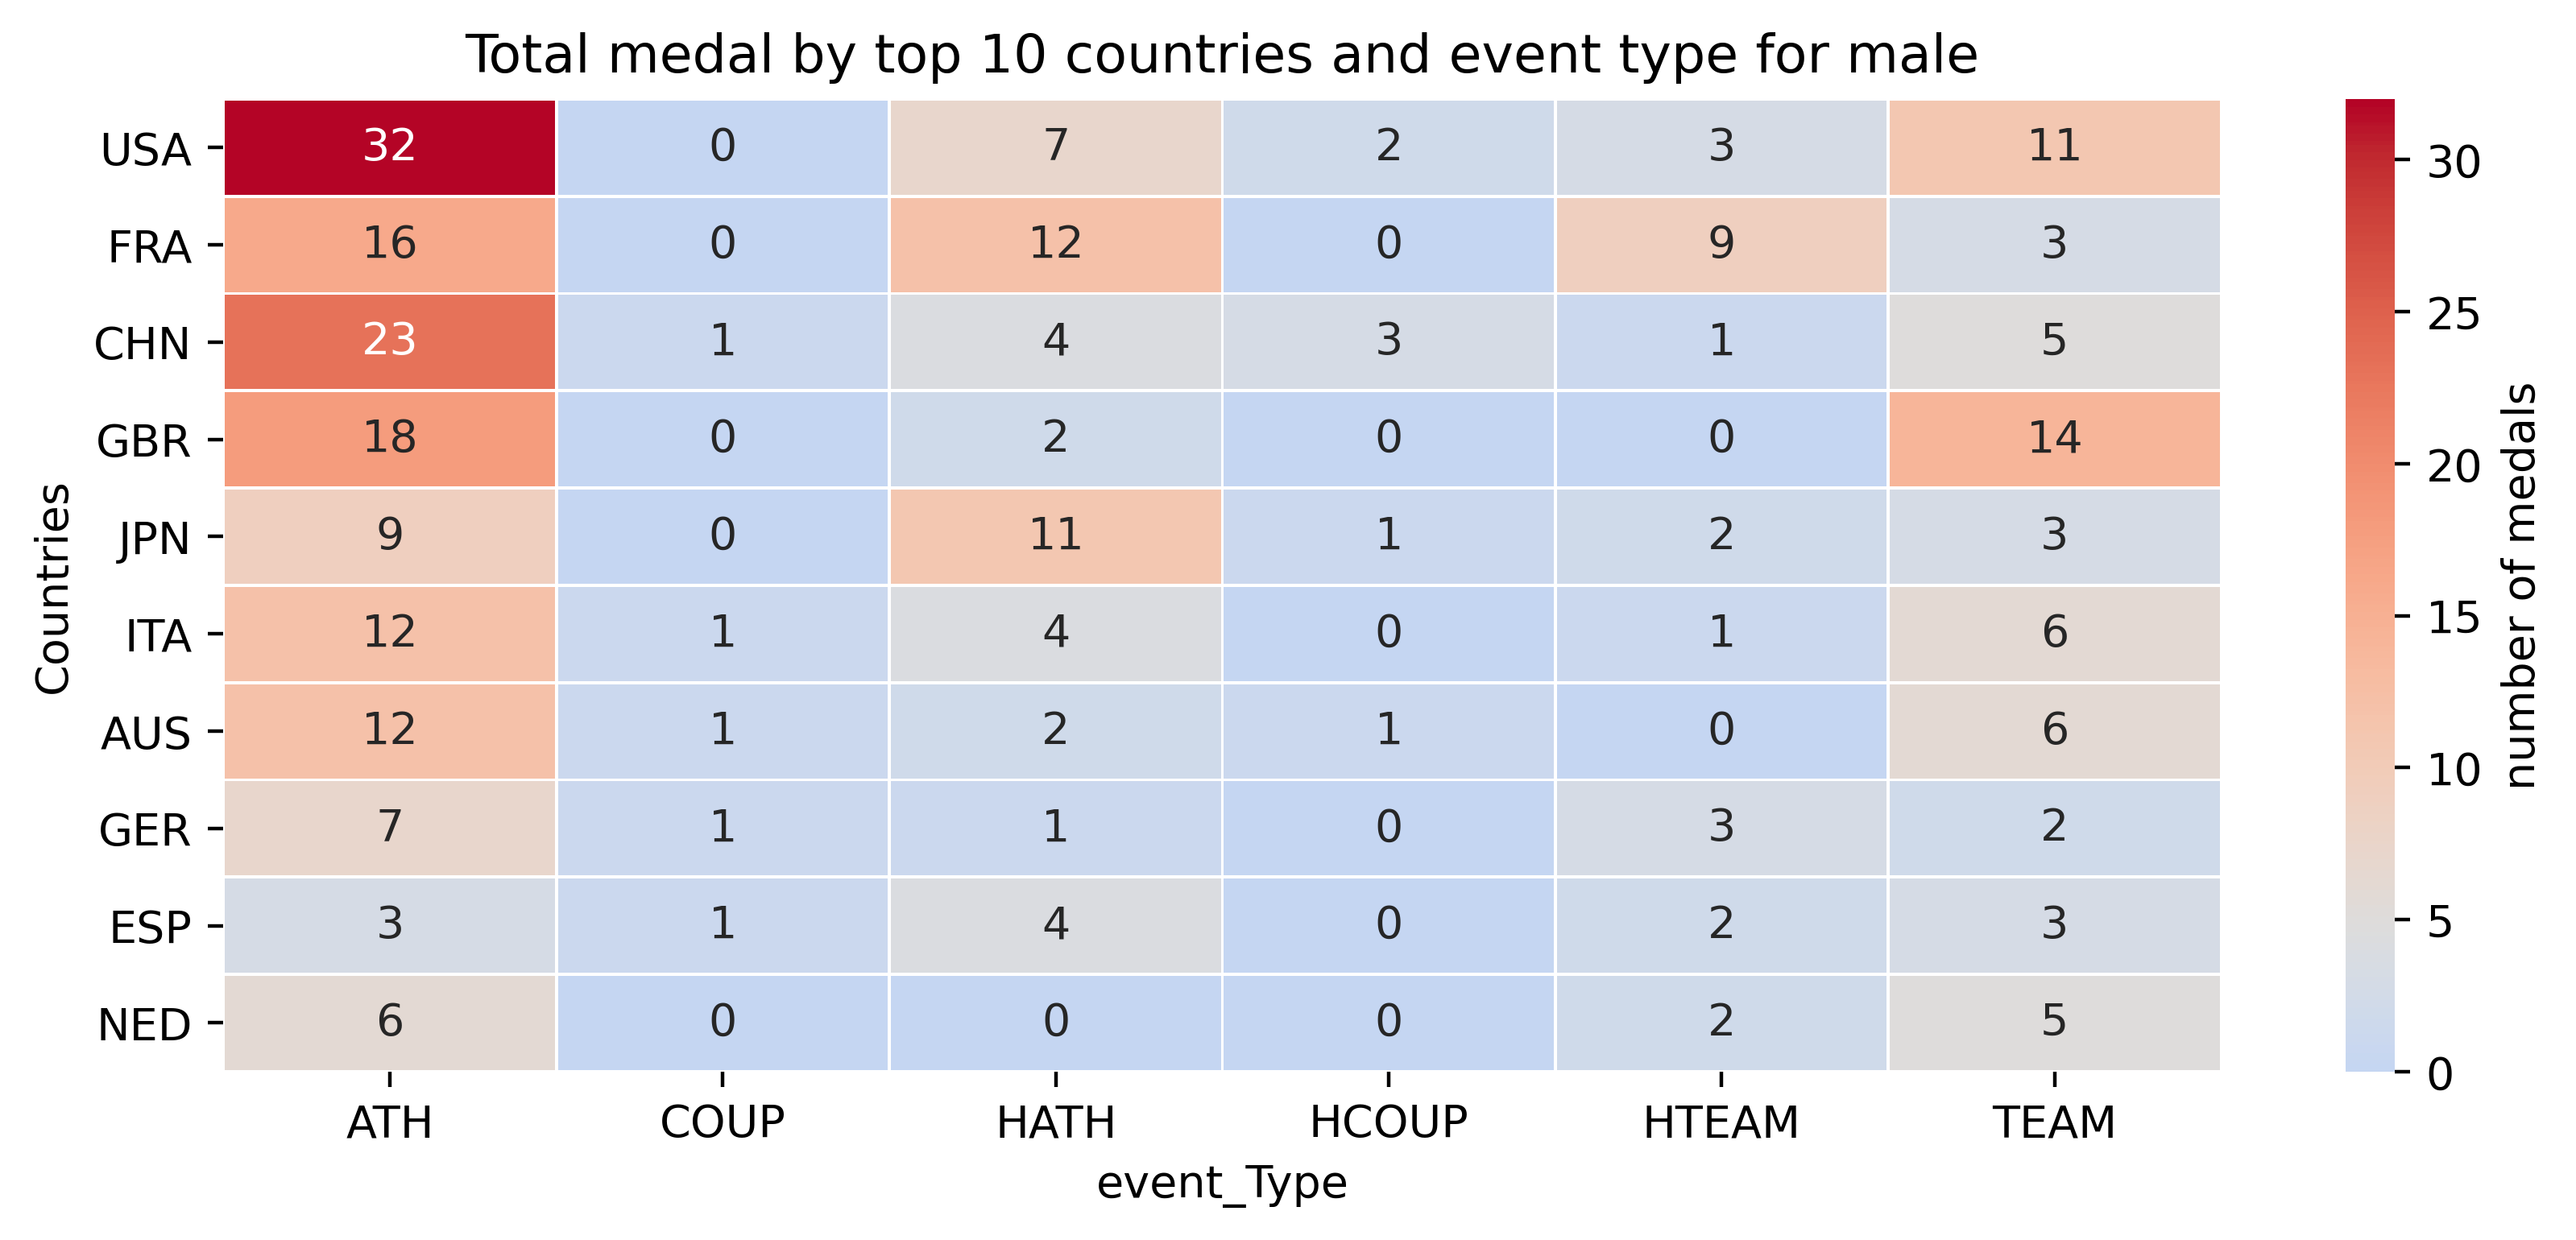

In [129]:
plot_country_event_type_compare(male_df, 'Total medal by top 10 countries and event type for male')

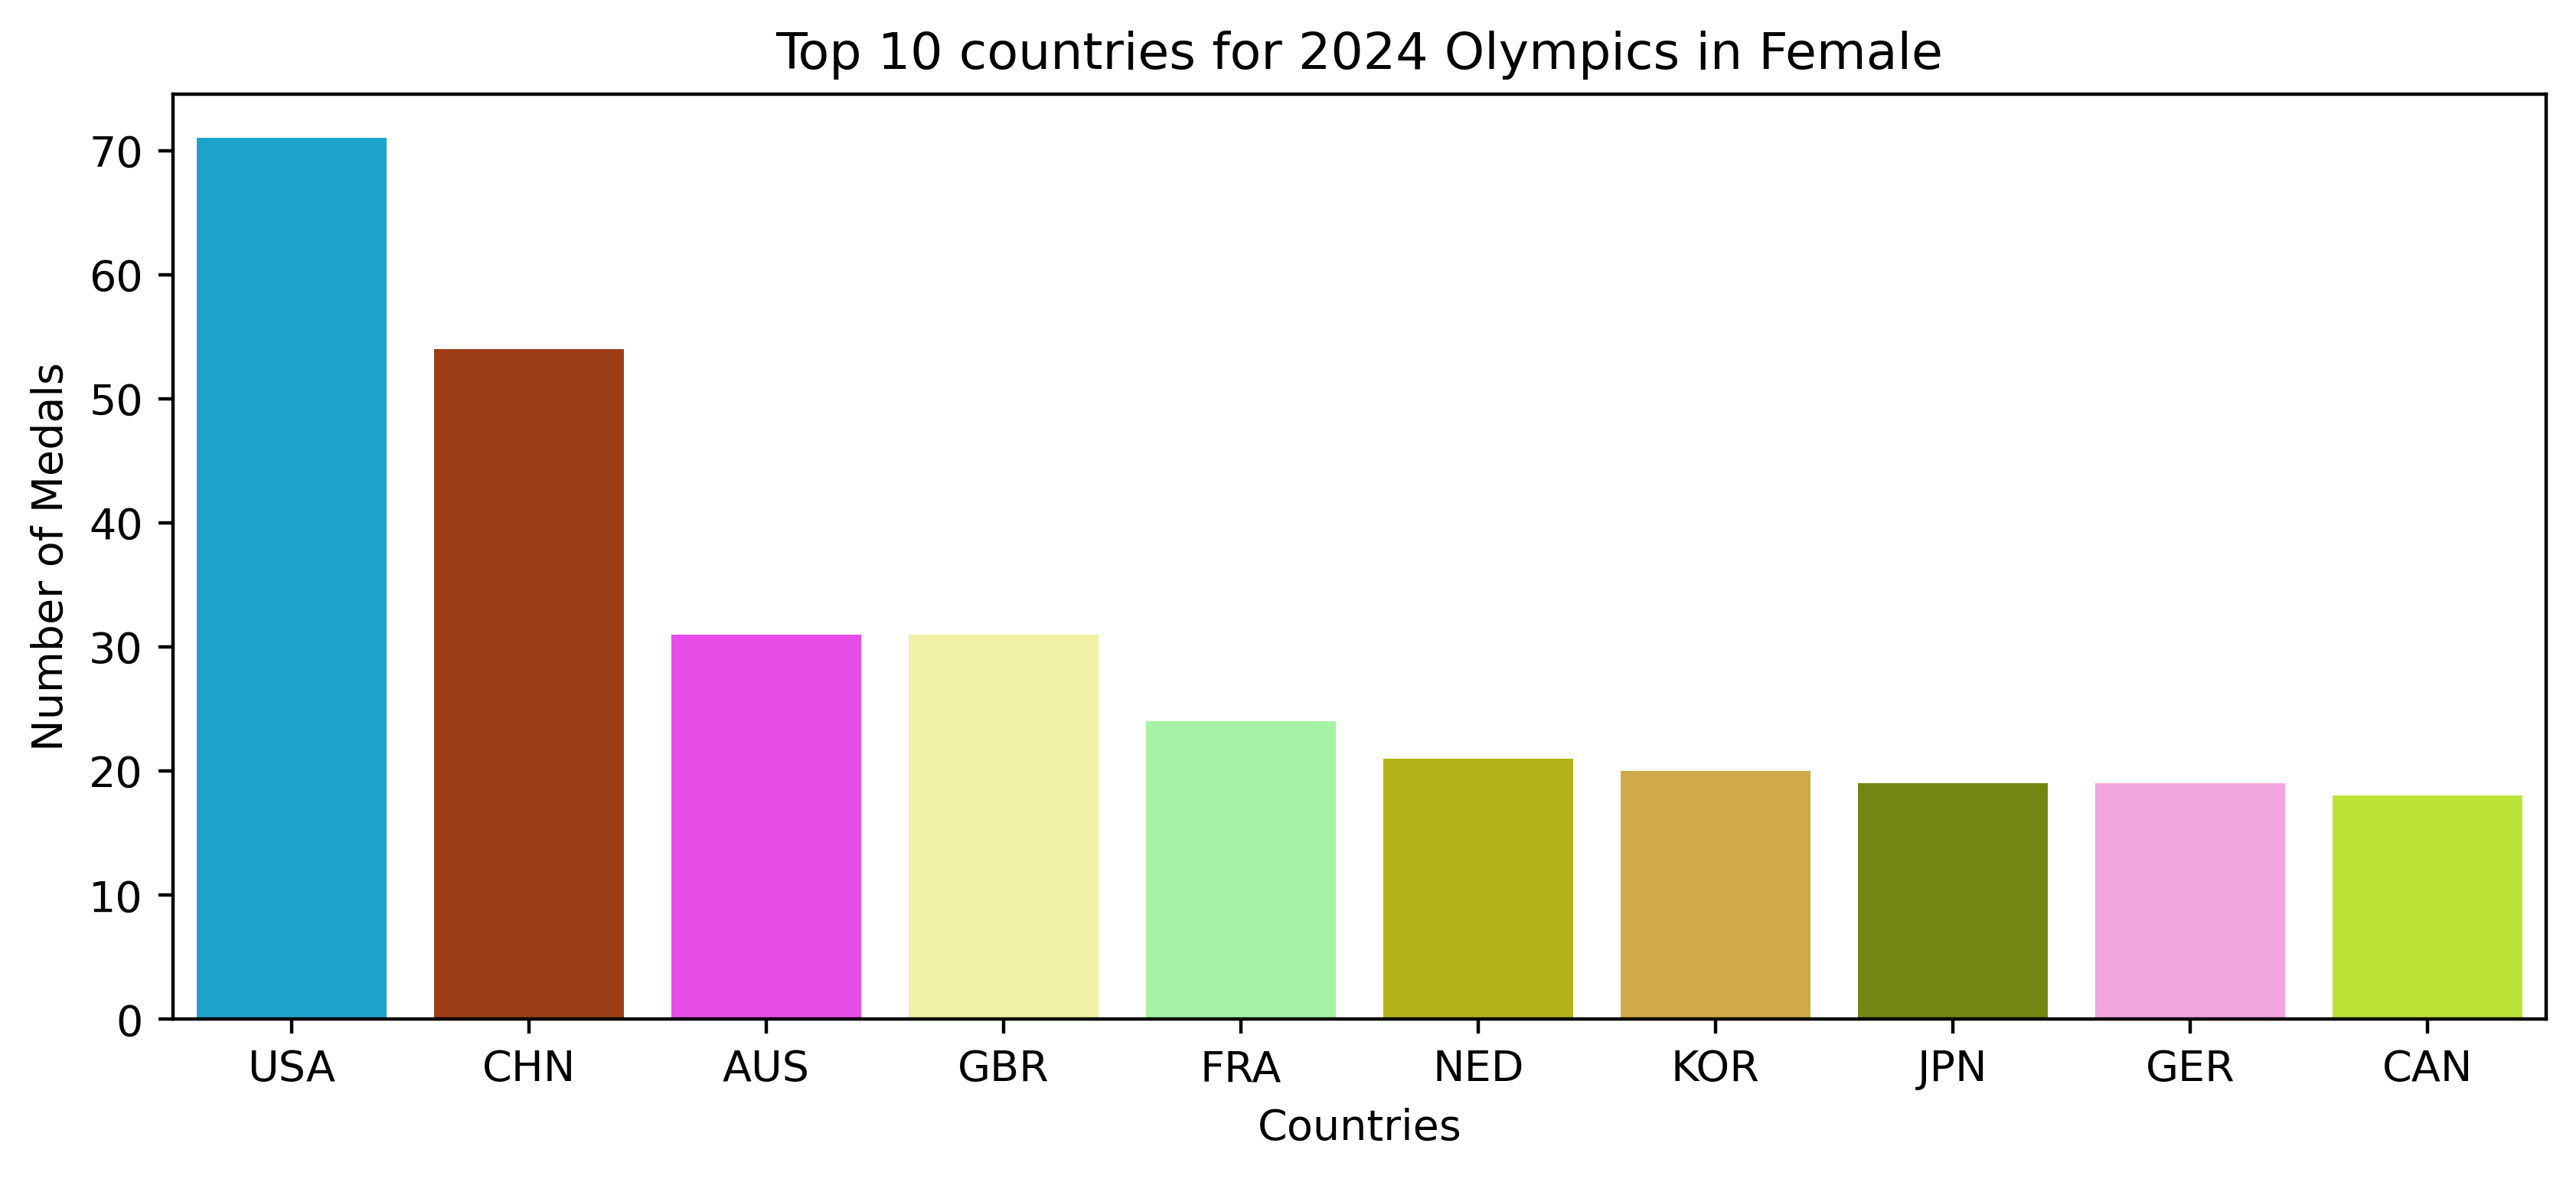

In [130]:
#FInding the top 10 countries for female 
#Filtering the dataframe to include only female records
female_df = df[df['gender'] == 'Female']
female_df = female_df.groupby('country_code').size().reset_index(name='count')

#Sort in descending order
sorted_female_df = female_df.sort_values(by = 'count', ascending = False)

#Plotting the bargraph
plt.figure(figsize =(10,4))
ax = sns.barplot(x = 'country_code', y = 'count', data = sorted_female_df, order=sorted_female_df['country_code'].head(10), palette = color_dict)

plt.title('Top 10 countries for 2024 Olympics in Female')
plt.xlabel('Countries')
plt.ylabel('Number of Medals')

#bars= ax.patches

# Create a container from the bars for bar_label()
#from matplotlib.container import BarContainer
#container = BarContainer(bars, orientation='vertical')

#ax.bar_label(ax.container[0] )
plt.show()

<Figure size 4000x1600 with 0 Axes>

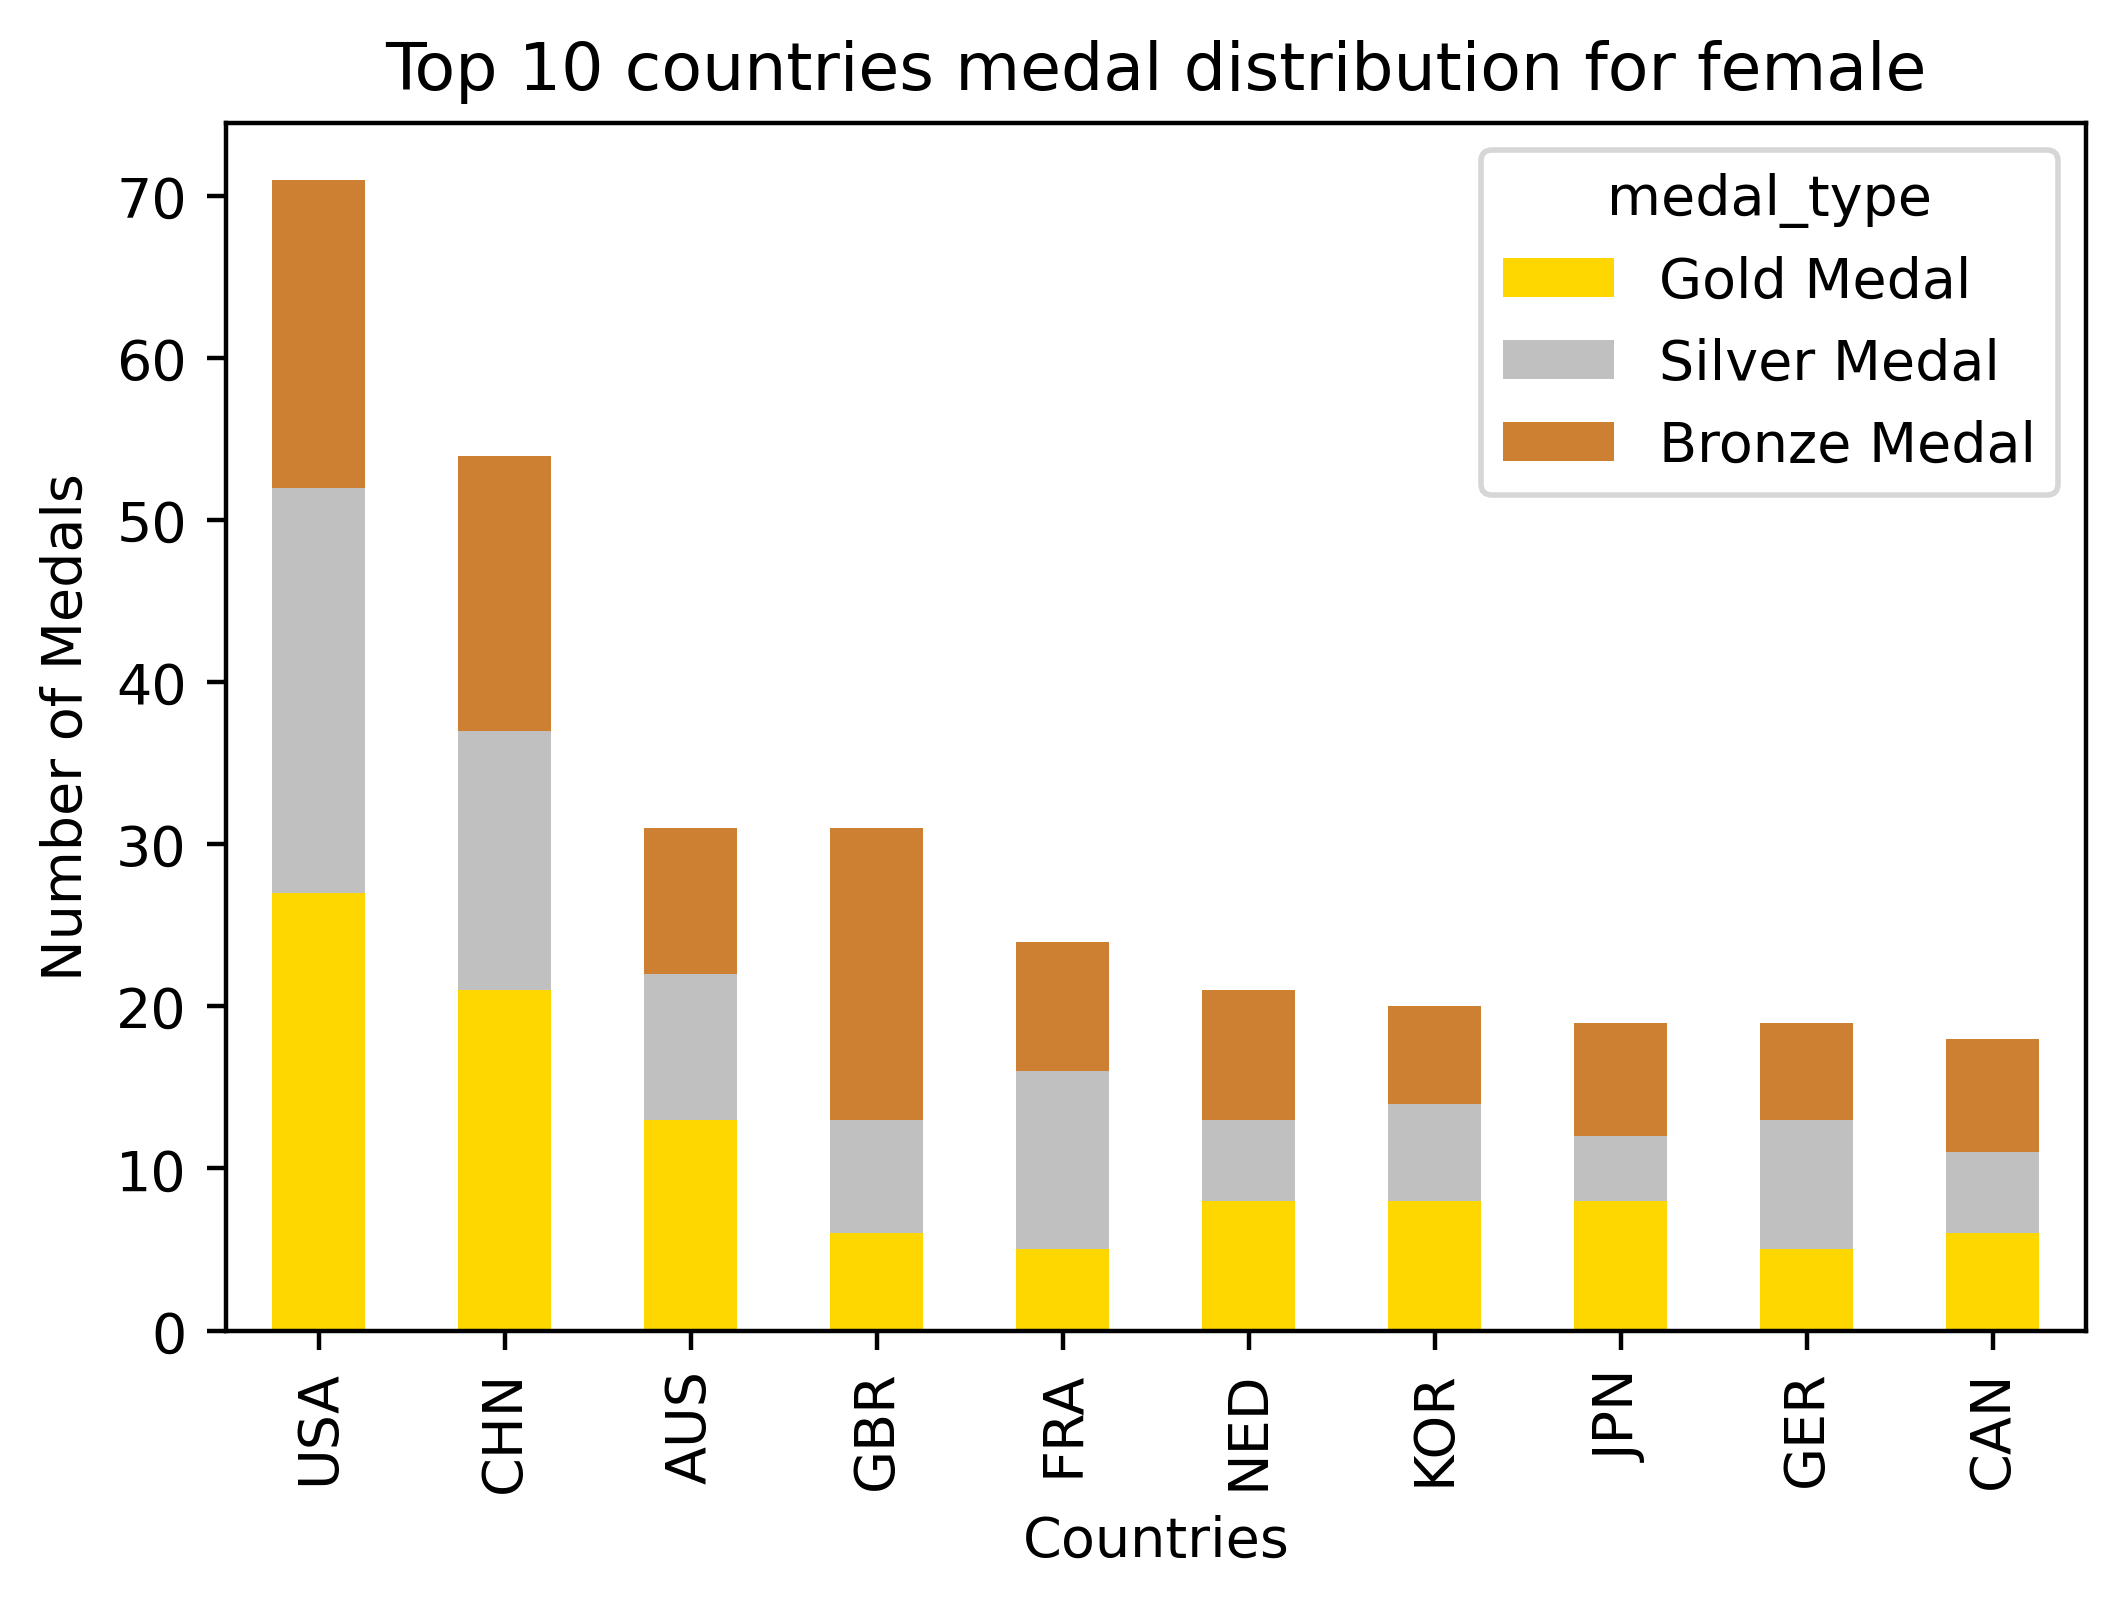

In [131]:
#FInding the top 10 countries for female 
#Filtering the dataframe to include only female records
female_df = df[df['gender'] == 'Female']
plot_medal_count_bar(female_df , 'Top 10 countries medal distribution for female')

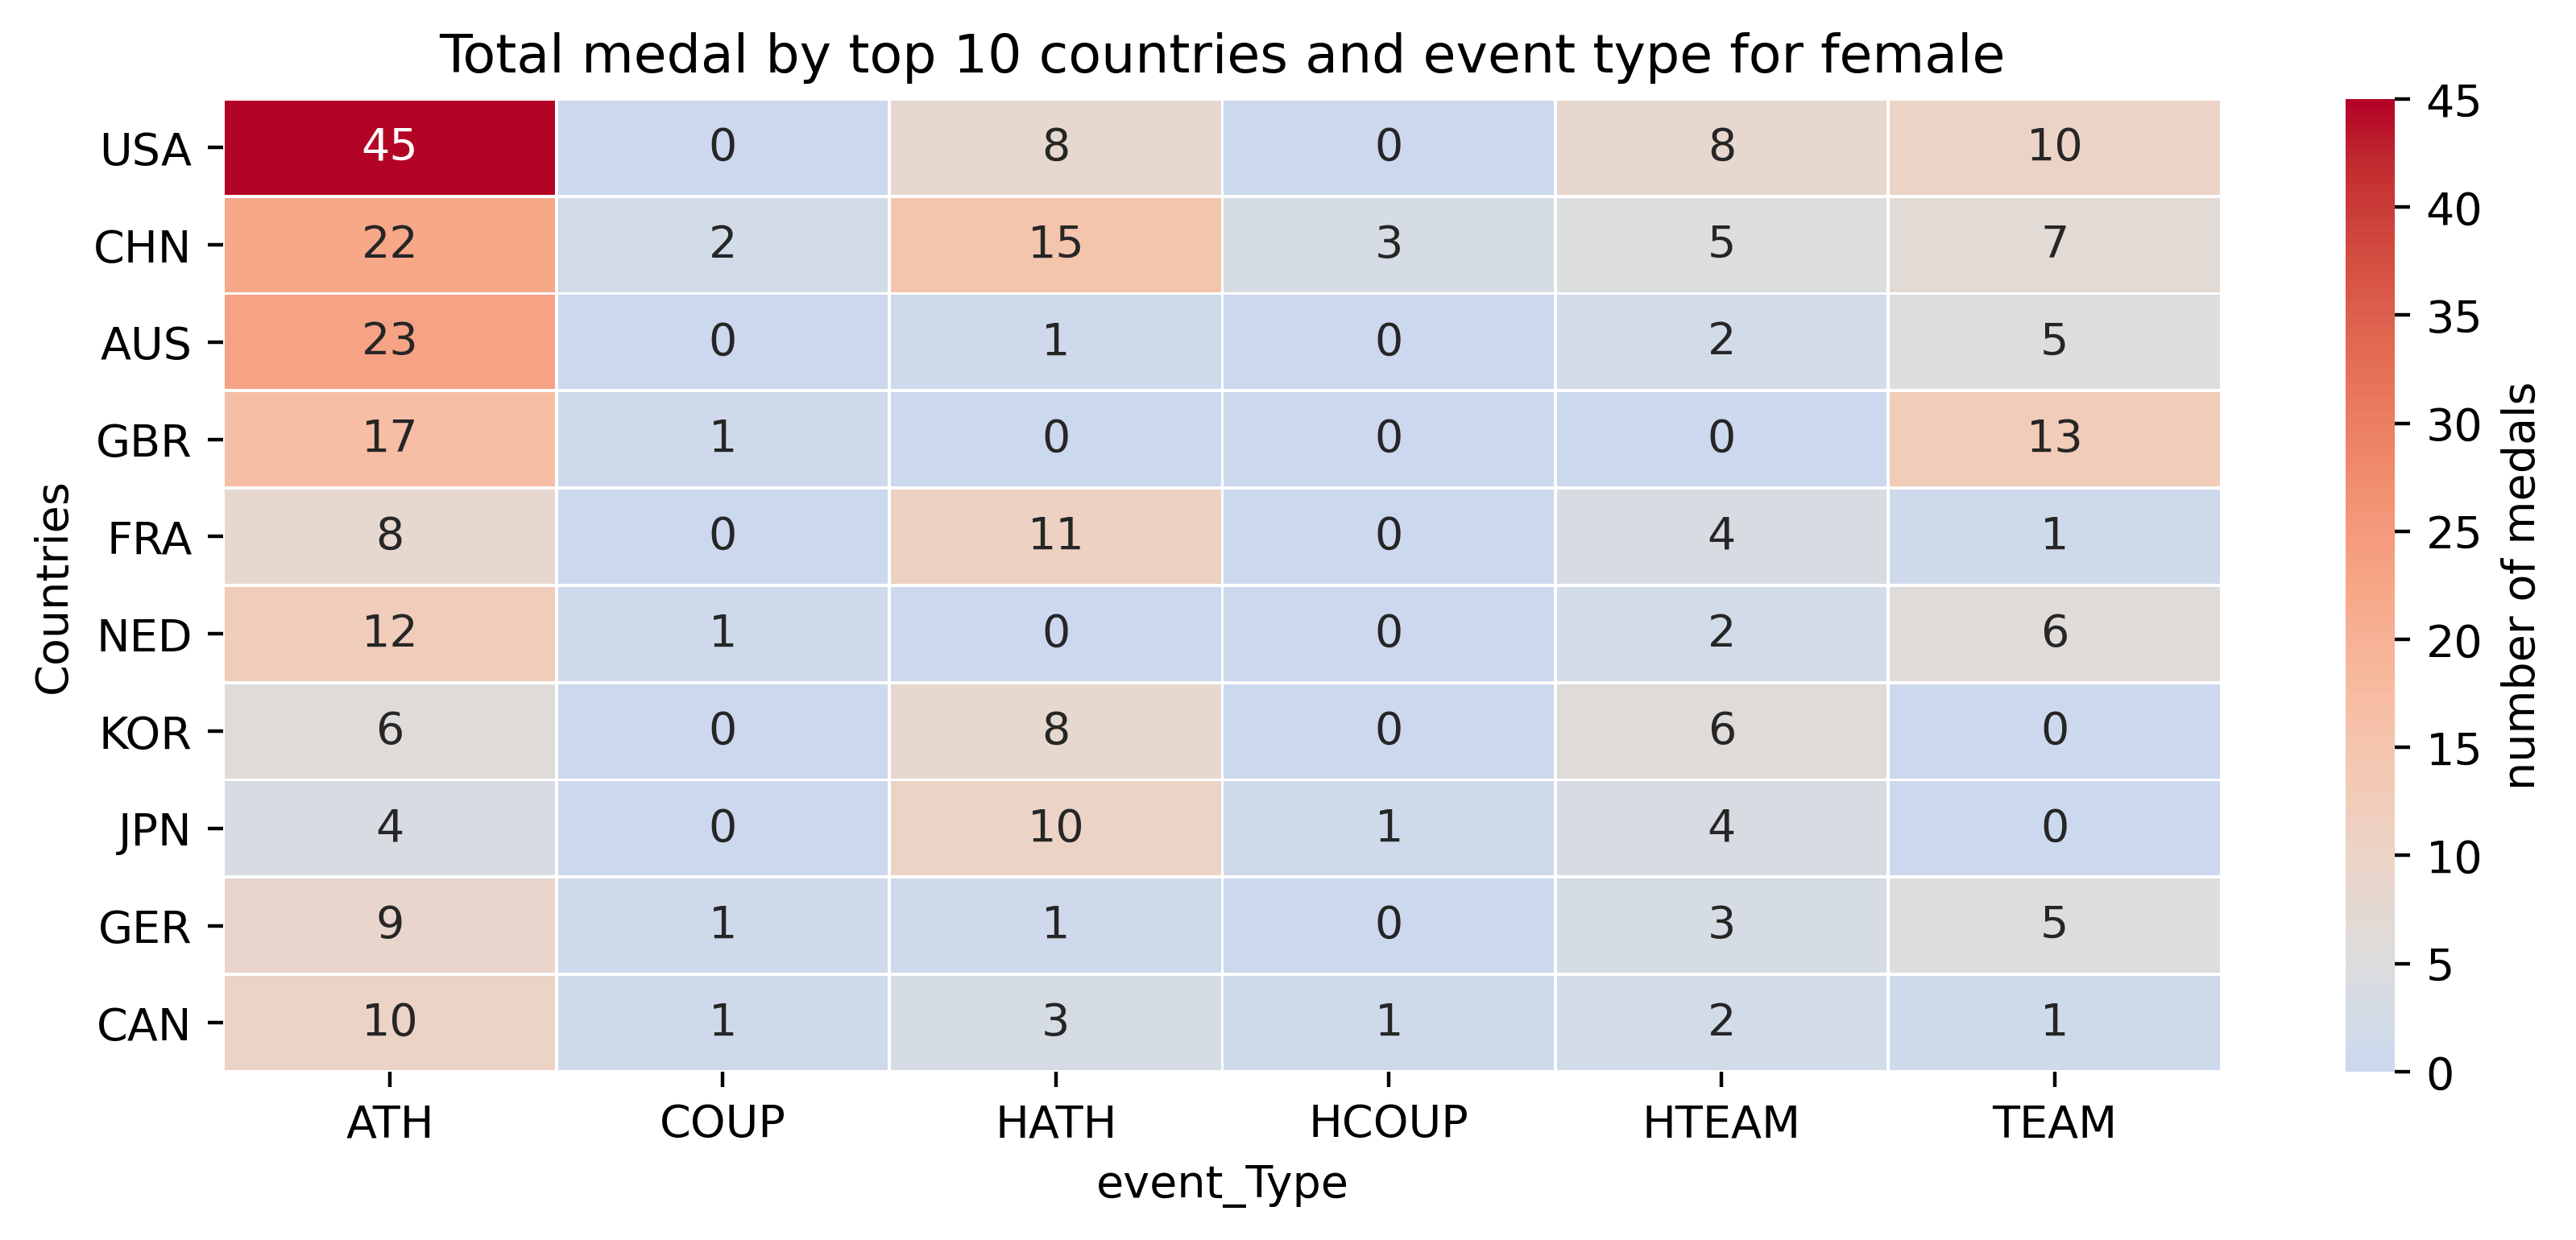

In [132]:
plot_country_event_type_compare(female_df, 'Total medal by top 10 countries and event type for female')

In [133]:
#Printing the distribution of the count in a geographical map
#Chloropleth function visualizes the data aggregated or averaged across regions
#Importing library to plot across geographical locations
import plotly.express as px

geo_distribution = px.choropleth(cumulative_df , locations = 'country_code' , color = 'count', hover_name = 'country_code',
                                projection = 'equirectangular', title = 'Medal Distribution for 2024 Olympics')

geo_distribution.show()

In [134]:
df.to_csv('Q4_cleaned_data.csv')